# Model Introduction

## Factor Analysis

### Description:
Factor Analysis (FA) is a statistical method used to describe variability among observed,correlated variables in terms of a lower number of unobserved variables called **factors**. More specifically, it is a **latent variable model** that aims to explain the covariance between observed variables by attributing it to a small number of underlying factors. It assumes that the observed variables are linear combinations of some underlying (latent) factors plus an error term (unique variance).

**It essentially helps you find the "hidden drivers" behind your data**

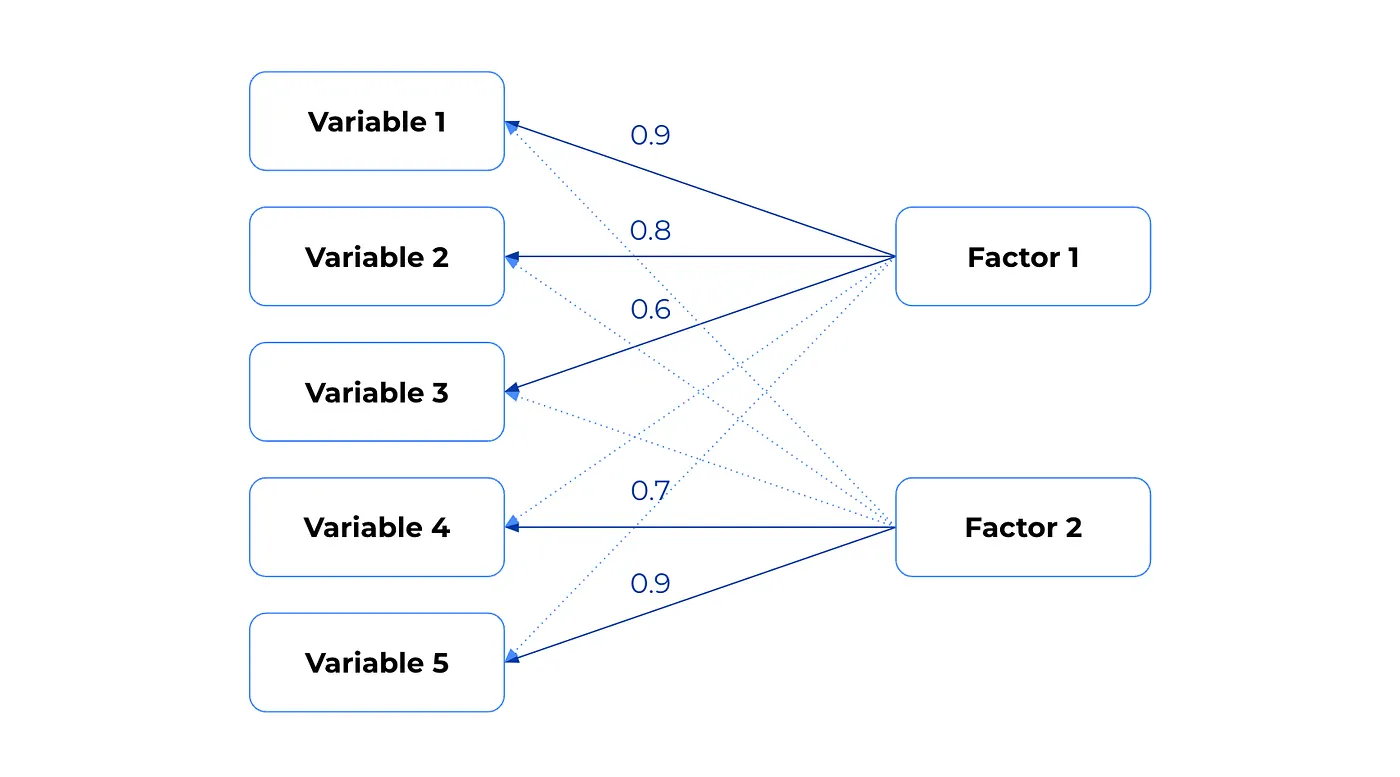

### Two Common Forms:
1) Exploratory FA (EFA): discover the factor structure (how many factors, which variables load on which).
2) Confirmatory FA (CFA): test a pre-specified structure (usually via SEM frameworks).

### Typical Usage:
1) Dimensionality reduction (with an interpretable latent structure, unlike generic PCA).
2) Construct measurement in psychometrics (e.g., “anxiety”, “satisfaction” factors).
3) Feature engineering for ML (replace 50 correlated variables with 5 factor scores).
4) Risk modeling / finance (latent “market”, “value”, “quality” style factors; or compressing correlated indicators).
5) Noise reduction (separate common signal vs variable-specific noise).

### Real-World Applications: 
1) **Finance:** Identifying common risk factors (e.g., the Fama-French model) that drive stock returns (https://corporatefinanceinstitute.com/resources/data-science/factor-analysis/).
2) **Psychometrics:** In psychology, factor analysis was used to condense thousands of personality-descriptive words into five core latent factors: Openness, Conscientiousness, Extraversion, Agreeableness, and Neuroticism (OCEAN) (https://pmc.ncbi.nlm.nih.gov/articles/PMC4104167/). 
3) **Marketing:** Marketers use exploratory factor analysis (EFA) to group various survey attributes (like "fast delivery," "friendly staff," and "low price") into broader latent constructs such as "Service Quality" or "Value for Money." (https://ieeexplore.ieee.org/document/10147469)

### Key Components & Mathematical Formulas:

**Main Formula**: Let $x \in R^p$ be the vector of **observed variables** (our inputs, after centering; often standardized) for one sample, then $$x = \mu + \Lambda f + \varepsilon$$

where:
1) $\mu \in R^p$: mean vector (expected values of observed variables)
2) $f \in R^m$: latent **factor** vector ($m \ll p$)
3) $\Lambda \in R^{p \times m}$: **loading matrix** (how each variable depends on factors)
4) $\varepsilon \in R^p$: unique (idiosyncratic) part / measurement error

**In Real Cases we usually have many samples rather than only one:** $$X = M + LF + \varepsilon$$
where: Observation Matrix $X \in R^{p \times n}$, Mean Matrix $M \in R^{p \times n}$, Loading Matrix $L \in R^{p \times m}$, Factor Matrix $F \in R^{m \times n}$, Error Term Matrix $\varepsilon \in R^{p \times n}$

**Assumptions**:

$f \sim \mathcal{N}(0, I_m)$ and $\varepsilon \sim \mathcal{N}(0, \Psi)$ 

where:
1) $\Psi = diag(\psi_1,...,\psi_p) \to$ factors are uncorrelated and have variance of 1
2) $Cov(f,\varepsilon) = 0 \to$ F and $\varepsilon$ are independent

**Covariance Structure**:

Set 
$$\Sigma = \operatorname{Cov}(\mathbf{x})$$

Substituting the model:
$$\Sigma = \Lambda\Lambda^T + \Psi$$

This decomposes covariance into:
1) Common Variance: $\Lambda\Lambda^T$
2) Unique Variance: $\Psi$

**Communality and Uniqueness**:

For variable j:

Communality:
$$h_j^2 = \sum_{k=1}^{m} \lambda_{jk}^2$$
where $\lambda =$ factor loadings $\to$ Communality = sum of the squared factor loadings across all $m$ extracted factors.

Uniqueness:
$$\psi_j = \Sigma_{jj} - h_j^2$$

If variables are standardied:
$$1 = h_j^2 + \psi_j$$

<b><u>Important Implications:</u></b>

Communality = how much of variable j’s variance is explained by the common factors
1) High $h_j^2 \to$ variable is well captured by the factor model (strongly “belongs” to the common structure).
2) Low $h_j^2 \to$ variable isn’t well explained by the extracted factors.

Uniqueness = how much variance in variable j is not explained by factors (idiosyncratic + measurement error)
1) High $\psi_j \to$ mostly unique/noisy; factors don’t explain it much.
2) Low $\psi_j \to$ mostly common/shared

What you can use them for (practical):
* **Variable-level model adequacy:** Check which variables are well represented by the factor solution (high $h_j^2$).
* **Feature selection / cleanup:** Drop or reconsider variables with very low communalities (they add noise more than shared structure).
* **Choosing number of factors $m$:** If many $h_j^2$ are low, you may need more factors (or a different model).
* **Interpretation:** Variables with high communality and strong loadings help you label factors; high uniqueness variables are less useful for interpretation.


**Identifiability**:

If $\mathbf{Q}$ is orthogonal:
$$\mathbf{Q}^T\mathbf{Q} = I$$
then
$$\Lambda^* = \Lambda^*\mathbf{Q}$$
produces the same covariance:
$$\Lambda^*(\Lambda^*)^T = \Lambda\Lambda^T$$
Therefore, the factor solution is not unique (rotation invariance)

<b><u>Simple Explanation: you can rotate the factor space and get different loadings and different factor scores that fit the data equally well, as long as they change in a coordinated way so the implied covariance (and $\Lambda f$ part) is unchanged</u></b>.


### Algorithm & Mathematical Formulatoin:

#### Data Preprocessing

Center data:
$$\tilde{x}_i = x_i - \hat{\mu}$$

Compute sample covariance:
$$S = \frac{1}{n} \sum_{i=1}^{n} \tilde{x}_i \tilde{x}_i^\top$$

#### Choose Number of Factors m
Note: FA is sensitive to sample size; small n can make m selection unstable. 

* **Eigenvalue inspection (scree plot)** -- Built-in for package **factor_analyzer**: Plot eigenvalues vs factor index → Scree Plot, and look for the “elbow” — where eigenvalues stop decreasing sharply.
* **Parallel analysis**: Keep factors only if real eigenvalue exceeds random benchmark -- More statistically grounded.
* **Information criteria (AIC/BIC)**

#### Maximum Likelihood Estimation

Objective:
$$\min_{\Lambda, \Psi} \left[ \log |\Sigma| + \operatorname{tr}(S \Sigma^{-1}) \right]$$

subject to:
$$\Sigma = \Lambda \Lambda^\top + \Psi$$

<b><u>Explain in words</u></b>:

**What MLE is trying to do:** (Best when data roughly normal)
1) You start with your real data and compute its covariance matrix S.
2) Factor Analysis proposes a model that should produce a similar covariance pattern.
3) MLE chooses $\Lambda$ and $\Psi$ so that the model’s covariance $\Sigma$ makes your observed data “as probable as possible” under a multivariate normal assumption.

**What the objective formula is doing:**

The objective is a numerical measure of mismatch between $S$ and $\Sigma$, when we minimize it, <u>we are trying to find the loadings and noise variances such that the covariance predicted by the factor model looks as close as possible to the covariance we see in the real data.</u>

**Other Common Methods for Factor Extractions:**
* Principal Axis Factoring (PAF): 
    * Does not assume normality
    * Based on eigen-decomposition
    * Best when Distributional assumptions are questionable
* Minimum Residual (MINRES)
    * Minimizes squared residuals of covariance
    * Computationally simple & Very stable
    * Best when Less strict assumptions

#### Rotation
To improve interpretability:
$$\Lambda_{rot} = \Lambda Q$$

where $Q$ maximizes a rotation criterion (e.g., Varimax):
$$\max_{Q} \sum_{j} \left[ \frac{1}{p} \sum_{i} \lambda_{ij}^4 - \left( \frac{1}{p} \sum_{i} \lambda_{ij}^2 \right)^2 \right]$$

* Rotation is done after we extract the factors.
* It does not change how well the model fits the data.
* It simply changes the way we look at the factors.
* The goal is to make the results easier to interpret.
* After rotation, each factor usually relates strongly to a smaller group of variables and weakly to others.
* This helps us clearly understand what each factor represents.
* Some rotations keep factors independent, while others allow them to be related.


#### Factor Score Estimation

Regression method:
$$\hat{f} = \Lambda^T \Sigma^{-1} x$$


### Package Selection

(1) scikit-learn — sklearn.decomposition.FactorAnalysis:

Scikit-learn provides a Maximum Likelihood implementation of Factor Analysis under a Gaussian assumption. Its main characteristics are:
* Uses Maximum Likelihood Estimation (MLE)
* Assumes orthogonal (uncorrelated) factors
* Optimizes model parameters via numerical optimization
* Provides factor loadings and factor scores
* Well-integrated with machine learning pipelines

However, it does not provide:
* Built-in rotation methods (e.g., Varimax, Promax)
* Multiple extraction methods
* Classical exploratory diagnostics (communalities, eigenvalues, etc.)

It is mainly designed as a dimensionality reduction tool within machine learning workflows.

(2) FactorAnalyzer — factor_analyzer.FactorAnalyzer

The factor_analyzer package is designed specifically for Exploratory Factor Analysis (EFA). It provides a more traditional statistical implementation of FA. Key features include:
* Multiple extraction methods:
    * Maximum Likelihood (ML)
    * Principal Axis Factoring (PAF)
    * Minimum Residual (MINRES)
* Built-in rotation methods:
    * Orthogonal (Varimax, Quartimax, Equamax)
    * Oblique (Promax, Oblimin)
* Direct access to communalities and uniqueness
* Eigenvalue inspection for factor selection

**Final Choice: factor_analyzer.FactorAnalyzer**
* The project focuses on interpretable latent structure, not just dimensionality reduction.
* Rotation methods (e.g., Varimax) are necessary for clearer factor interpretation.
* Multiple extraction options allow flexibility in modeling.
* It provides diagnostic outputs such as communalities and eigenvalues, which are important for evaluation.


## Agglomerative Clustering

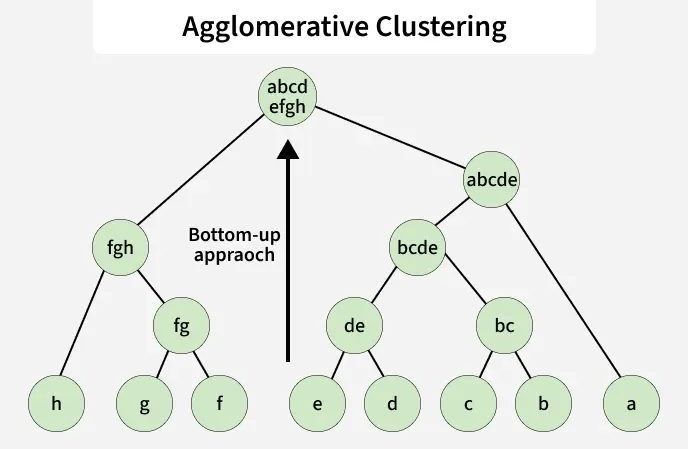

Agglomerative clustering is a **hierarchical clustering method** that starts by treating each data point as its own cluster. At each step, it calculates the distance between clusters and merges the two closest ones. This process continues step by step until a chosen number of clusters is reached or all data points are grouped into a single cluster. The merging process can be visualized using a dendrogram, which shows how clusters are combined over time.

Agglomerative clustering is mainly used to **discover natural groupings in data** and to **understand the hierarchical structure between observations**. It is useful when we want to explore how data points are related at different levels of similarity, such as grouping similar customers, stocks, or documents. It is especially helpful when the number of clusters is not clearly known in advance.

## Isolation Forest

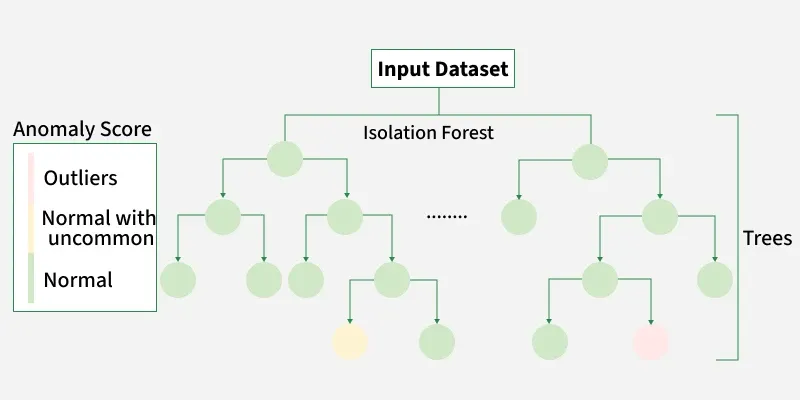

Isolation Forest is an anomaly detection algorithm that works by isolating observations instead of modeling normal data behavior. It builds many random decision trees by repeatedly selecting a random feature and a random split value. Points that are easier to isolate (i.e., require fewer splits to separate from the rest of the data) are considered more likely to be anomalies. Since anomalies are rare and different from normal observations, they tend to be separated quickly in the tree structure.

Isolation Forest is mainly used for detecting outliers or abnormal patterns in data. It is useful in applications such as fraud detection, network security, fault detection, and financial risk monitoring. The method is efficient for large datasets and does not require labeled anomaly data, making it practical for real-world unsupervised anomaly detection problems.

# Basic Example: Simulated Data for Factor Analysis

Before applying Factor Analysis to a real-world dataset, we demonstrate the
method using simulated data with a known latent factor structure. This example
helps illustrate how the algorithm identifies shared variance among observed
variables and recovers the underlying latent factors.

In [8]:
! pip install factor_analyzer

import numpy as np
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Step 1: Set random seed for reproducibility
# ----------------------------------------------------------
np.random.seed(42)

# ----------------------------------------------------------
# Step 2: Define dataset dimensions
# n = observations
# p = observed variables
# k = latent factors
# ----------------------------------------------------------
n = 500
p = 9
k = 3

# ----------------------------------------------------------
# Step 3: Simulate latent factor values
# Each row represents latent factor values for one observation
# ----------------------------------------------------------
F = np.random.normal(0, 1, size=(n, k))

# ----------------------------------------------------------
# Step 4: Define the true factor loading structure
# Variables are designed so that:
# X1–X3 load mainly on Factor 1
# X4–X6 load mainly on Factor 2
# X7–X9 load mainly on Factor 3
# ----------------------------------------------------------
loadings_true = np.array([
    [0.85, 0.10, 0.05],
    [0.80, 0.15, 0.10],
    [0.75, 0.05, 0.10],
    [0.10, 0.80, 0.10],
    [0.15, 0.75, 0.05],
    [0.05, 0.85, 0.10],
    [0.10, 0.05, 0.80],
    [0.05, 0.10, 0.75],
    [0.10, 0.15, 0.85]
])

# ----------------------------------------------------------
# Step 5: Add noise (unique variance / measurement error)
# ----------------------------------------------------------
noise = np.random.normal(0, 0.4, size=(n, p))

# ----------------------------------------------------------
# Step 6: Generate observed variables
# X = F * L' + noise
# ----------------------------------------------------------
X = F @ loadings_true.T + noise

columns = [f"X{i}" for i in range(1, p + 1)]
df = pd.DataFrame(X, columns=columns)

print("First 5 rows of simulated data:")
print(df.head())

# ----------------------------------------------------------
# Step 7: Examine correlation matrix
# Factor Analysis requires correlated variables
# ----------------------------------------------------------
corr_matrix = df.corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# ----------------------------------------------------------
# Step 8: Test suitability for Factor Analysis
# Bartlett test + KMO
# ----------------------------------------------------------
chi_square_value, p_value = calculate_bartlett_sphericity(df)
kmo_all, kmo_model = calculate_kmo(df)

print("\nBartlett's Test")
print("Chi-square:", round(chi_square_value, 3))
print("p-value:", p_value)

print("\nKMO Test")
print("Overall KMO:", round(kmo_model, 3))

# ----------------------------------------------------------
# Step 9: Inspect eigenvalues
# Helps determine number of factors
# ----------------------------------------------------------
fa_check = FactorAnalyzer(rotation=None)
fa_check.fit(df)

eigenvalues, _ = fa_check.get_eigenvalues()

eigen_df = pd.DataFrame({
    "Factor": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues
})

print("\nEigenvalues:")
print(eigen_df.round(3))

# ----------------------------------------------------------
# Step 10: Train-test split
# ----------------------------------------------------------
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# ----------------------------------------------------------
# Step 11: Fit Factor Analysis model
# Using varimax rotation for interpretability
# ----------------------------------------------------------
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(train_df)

# ----------------------------------------------------------
# Step 12: Extract estimated loadings
# ----------------------------------------------------------
loadings_est = pd.DataFrame(
    fa.loadings_,
    index=train_df.columns,
    columns=[f"Factor{i}" for i in range(1, 4)]
)

print("\nEstimated Factor Loadings:")
print(loadings_est.round(3))

# ----------------------------------------------------------
# Step 13: Communalities
# ----------------------------------------------------------
communalities = pd.Series(
    fa.get_communalities(),
    index=train_df.columns
)

print("\nCommunalities:")
print(communalities.round(3))

# ----------------------------------------------------------
# Step 14: Variance explained
# ----------------------------------------------------------
variance = fa.get_factor_variance()

variance_df = pd.DataFrame({
    "SS Loadings": variance[0],
    "Proportion Variance": variance[1],
    "Cumulative Variance": variance[2]
}, index=[f"Factor{i}" for i in range(1, 4)])

print("\nVariance Explained:")
print(variance_df.round(3))

# ----------------------------------------------------------
# Step 15: Factor scores (apply model to data)
# ----------------------------------------------------------
train_scores = pd.DataFrame(
    fa.transform(train_df),
    columns=[f"Factor{i}_Score" for i in range(1, 4)]
)

test_scores = pd.DataFrame(
    fa.transform(test_df),
    columns=[f"Factor{i}_Score" for i in range(1, 4)]
)

print("\nFirst 5 training factor scores:")
print(train_scores.head())

print("\nFirst 5 test factor scores:")
print(test_scores.head())

# ----------------------------------------------------------
# Step 16: Sensitivity analysis
# Compare models with different factor counts
# ----------------------------------------------------------
results = []

for nf in [2, 3, 4]:
    fa_temp = FactorAnalyzer(n_factors=nf, rotation="varimax")
    fa_temp.fit(train_df)

    var = fa_temp.get_factor_variance()

    results.append({
        "n_factors": nf,
        "Total Variance Explained": var[2][-1]
    })

sensitivity_df = pd.DataFrame(results)

print("\nSensitivity Analysis:")
print(sensitivity_df.round(3))

521.52s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=dcc3d2bbf4d6229d650438cba0625eb254abb9a4ed4dc6df1141bad1628b0bd2
  Stored in directory: /Users/lucylu/Library/Caches/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer
First 5 rows of simulated data:
         X1        X2        X3        X4        X5        X6        X7  \
0  0.752109  0.220926  0.103112  0.002479 -0.064881 -0.209211  0.839464   
1  1.850465  0.703212  1.029687 -0.345162 -0.705482 -0.179365 -0.095413   
2  0.985926  2.073175  1.664247  0.957761  0.698391  0.300557 -0.328169   
3  1.008845  0.122423 -0.110671 -0.306697 -0.996841 -0.284083 -0.400540   
4  0.133534 -0.478994 -0.554651 -2

### Explanation

This simulated example demonstrates the full Factor Analysis workflow using a controlled dataset with a known latent structure.

**Estimation results.**  
The estimated factor loadings should recover the intended simulation design, where variables X1–X3 load primarily on one factor, X4–X6 on a second factor, and X7–X9 on a third factor. The communalities indicate how much of each observed variable’s variance is explained by the common factors, while the variance-explained results show that the extracted factors capture most of the shared structure in the data.

**Training.**  
The Factor Analysis model was fit on the training subset of the simulated dataset using the `factor_analyzer` package with three factors and varimax rotation. This rotation improves interpretability by making the loading structure cleaner, so that each variable tends to load strongly on one factor and weakly on the others.

**Testing.**  
Although Factor Analysis is an unsupervised learning method and does not predict a labeled target, the fitted model can still be applied to unseen observations. The test dataset was transformed into factor scores using the factor structure estimated from the training set, showing that the learned latent dimensions can be consistently applied to new data.

**Sensitivity analysis.**  
The robustness of the factor specification was evaluated by comparing models with two, three, and four factors. The two-factor model explained **56.2%** of the variance, the three-factor model explained **79.5%**, and the four-factor model explained **81.0%**. This suggests that moving from two to three factors provides a substantial improvement in explanatory power, while adding a fourth factor yields only a marginal gain. Therefore, the three-factor solution provides the best balance between interpretability, parsimony, and goodness of fit.

**Interpretation.**  
Overall, the results show that Factor Analysis can successfully recover the shared latent structure embedded in the simulated data. This confirms that the modeling workflow and package choice are appropriate before applying the method to a real-world dataset.

**Prediction (if applicable).**  
While Factor Analysis is not primarily designed for supervised prediction, the estimated factor scores provide low-dimensional representations of each observation in the latent factor space. These scores can be used in downstream tasks such as clustering, visualization, anomaly detection, or as inputs to predictive models.

# Real-World Application

## Latent Factor Decomposition, Regime Clustering, and Tail Risk Detection in U.S. Treasury Yield Curve for Market Risk Management

### 1. Project Overview

**Objective:** Build a market-risk style framework for the U.S. Treasury yield curve that:
1) extracts a small set of systematic rate-shock drivers using factor analysis,
2) evaluates the stability of the factor structure across regimes, and
3) uses the resulting factor shocks for regime classification and tail-event detection.

#### Data
- **Instrument:** U.S. Treasury Constant Maturity yields (nominal), daily frequency  
- **Maturities:** 1M, 3M, 6M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y  
- **Time range:** 2010-01-04 to 2024-12-31  
- **Source:** FRED (Federal Reserve Economic Data)  
- **Model input:** daily changes in yields ($\Delta y$) in **basis points**, standardized using training-period statistics.

<b><u>Why we choose these 9 U.S. Treasury Constant Maturity yield curves</u></b>

- **Full curve coverage with balanced maturity buckets:** We select 9 representative maturities spanning the **front end** (1M, 3M, 6M), **short/intermediate sector** (1Y, 2Y, 5Y), and **long end** (10Y, 20Y, 30Y) to ensure the model captures co-movement across the entire Treasury term structure rather than concentrating on one region.
- **Parsimony without excessive redundancy:** The chosen maturities provide a broad yet manageable representation of the curve. They are sufficiently spaced to preserve the main shape information while avoiding over-weighting nearby maturities that often contain highly redundant information (we exclude 7Y).



<b><u>Why we model daily yield changes (Δy) instead of yield levels (y)</u></b>

This project is framed as a **market risk** analysis. Market risk systems (e.g., VaR, stress testing, risk attribution) are driven by **daily shocks** to risk factors, because a fixed-income portfolio’s short-horizon P&L is primarily a function of **yield movements**, not yield levels.

- **P&L linkage:** For small moves, bond price changes are approximately proportional to yield changes (duration-based approximation), so daily risk is naturally tied to Δy.
- **Risk covariance:** We want the covariance of day-to-day co-movements across maturities (how rates *move together*), which is more stable and interpretable when modeling changes.
- **Robustness for validation:** Using Δy supports time-based train/test validation of factor stability across regimes (e.g., pre- vs post-stress periods) without the long-run trend dominating the factor structure.

#### Models and Python packages
- **Factor extraction (core):** `factor_analyzer.FactorAnalyzer`  
  Used to estimate factor loadings and produce daily factor shocks (e.g., Level/Slope/Curvature-like drivers).
- **Regime labeling:** `sklearn.cluster.AgglomerativeClustering`  
  Applied to factor shocks to segment the market into a small number of regimes (normal vs stress-like states).
- **Tail / anomaly alerts:** `sklearn.ensemble.IsolationForest`  
  Applied to factor shocks to flag extreme or unusual days for monitoring and model-risk awareness.

#### Outputs 
- Daily **factor shocks**, **regime label**, and **tail alert** flags  
- Diagnostics: out-of-sample reconstruction quality, regime-dependent factor volatility, and examples of flagged stress dates

### 2. Package Import

In [ ]:
import os
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Factor Analysis
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import AgglomerativeClustering

# Anomaly detection
from sklearn.ensemble import IsolationForest

# Statistical testing (optional but useful)
from statsmodels.tsa.stattools import adfuller, kpss

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


### 3. Read Datasets & Data Overview

In [ ]:
###Read Datasets
data_dir = "data"

series_codes = ["DGS1MO", "DGS3MO", "DGS6MO", "DGS1", "DGS2", "DGS5", "DGS10", "DGS20", "DGS30"]

dfs = []
for code in series_codes:
    path = os.path.join(data_dir, f"{code}.csv")
    df = pd.read_csv(path)

    df.columns = ["Date", code]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")

    df[code] = pd.to_numeric(df[code], errors="coerce")

    dfs.append(df)

yields = pd.concat(dfs, axis=1).sort_index()

print("Shape:", yields.shape)
print("Date range:", yields.index.min().date(), "to", yields.index.max().date())
yields.head()

Shape: (3912, 9)
Date range: 2010-01-04 to 2024-12-31


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS20,DGS30
Date,,,,,,,,,
2010-01-04,0.05,0.08,0.18,0.45,1.09,2.65,3.85,4.60,4.65
2010-01-05,0.03,0.07,0.17,0.41,1.01,2.56,3.77,4.54,4.59
2010-01-06,0.03,0.06,0.15,0.40,1.01,2.60,3.85,4.63,4.70
2010-01-07,0.02,0.05,0.16,0.40,1.03,2.62,3.85,4.62,4.69
2010-01-08,0.02,0.05,0.15,0.37,0.96,2.57,3.83,4.61,4.70


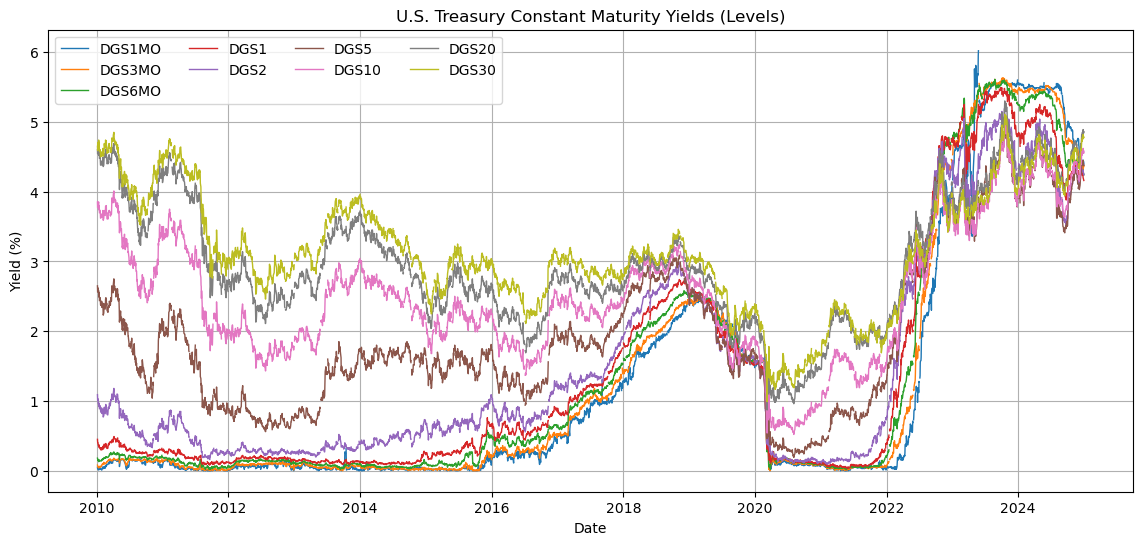

In [ ]:
###Plot all 9 yield curves
plt.figure(figsize=(14, 6))
for code in series_codes:
    plt.plot(yields.index, yields[code], label=code, linewidth=1)

plt.title("U.S. Treasury Constant Maturity Yields (Levels)")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend(ncol=4)
plt.grid(True, alpha=1)
plt.show()


<b><u>Core Insights From The Plot Above:</u></b>

* **Macro/market overview (rate regime narrative):** Yields across maturities move together strongly, suggesting that a small number of common shocks explain most day-to-day curve movements. Factor Analysis compresses the nine correlated yield series into a few latent factors that capture their shared covariance structure. Empirical research on Treasury yields (e.g., Litterman & Scheinkman, 1991) shows that the dominant modes of yield variation typically resemble level, slope, and curvature movements of the yield curve. Extracting such factors allows clearer risk attribution, covariance stabilization, and scenario design (e.g., applying a +1σ factor shock rather than separate shocks to each maturity).
* **Why Factor Analysis (risk driver compression + interpretability):** Yields across maturities move together strongly (high co-movement), suggesting that a small number of common shocks explain most day-to-day curve movement. Factor Analysis converts 9 correlated yield series into a few interpretable systematic risk drivers (typically Level/Slope/Curvature), enabling clearer risk attribution, covariance stabilization, and scenario design (e.g., “+1σ level shock” rather than separate shocks to each maturity).
* **Why Regime clustering + tail/anomaly detection (non-stationarity + stress behavior):** The plot reveals volatility clustering and structural breaks (e.g., 2020 and 2022–2023), meaning the factor distribution and covariance structure can differ by regime. Regime clustering helps segment “normal vs stress” states and quantify regime-dependent risk (factor vol/correlation changes), while anomaly detection flags extreme days and potential structural breaks for monitoring, stress testing, and model governance.

### 4. Data Quality & Outlier Check

In [ ]:
###Missing value check (holidays / non-trading days / data gaps)
missing_counts = yields.isna().sum()
print("Missing counts:\n", missing_counts)

Missing counts:
 DGS1MO    160
DGS3MO    160
DGS6MO    160
DGS1      160
DGS2      160
DGS5      160
DGS10     160
DGS20     160
DGS30     160
dtype: int64


* **Missingness is synchronized across maturities (same 160 dates)** → likely holidays/non-reporting days (good sign) $\to$ **we simply drop all NA**

In [ ]:
###Outlier sanity check on daily changes in bps
yields_clean = yields.dropna(how="any").copy()     
dy_bp = yields_clean.diff().dropna() * 100         

# Summary of extreme moves per maturity
outlier_summary = pd.DataFrame({
    "max_abs_move_bps": dy_bp.abs().max(),
    "p99_abs_move_bps": dy_bp.abs().quantile(0.99),
    "p999_abs_move_bps": dy_bp.abs().quantile(0.999),
}).sort_values("max_abs_move_bps", ascending=False)

outlier_summary

,max_abs_move_bps,p99_abs_move_bps,p999_abs_move_bps
DGS1MO,106.0,16.0,43.75
DGS1,60.0,13.5,29.25
DGS2,57.0,17.0,28.50
DGS6MO,36.0,10.0,21.25
DGS20,35.0,16.0,25.25
DGS3MO,34.0,11.0,22.00
DGS5,32.0,18.0,28.00
DGS30,31.0,15.5,28.00
DGS10,30.0,16.0,23.50


### 5. Train/Test policy (time-series validation and governance)

Because yield movements are time-dependent, we use a **chronological split** rather than random sampling to avoid information leakage.

- **Training period:** 2010–2019  
  Used to estimate the factor structure (loadings) and scaling parameters (mean/std for standardization).
- **Testing period:** 2020–2024  
  Used for out-of-sample validation during materially different market conditions (COVID shock, inflation, tightening cycle).

<b><u>By projecting post-2020 yield changes onto the factor structure estimated from 2010–2019, we evaluate:</u></b>

- Whether the learned covariance structure remains stable under stress
- Whether the same latent factors still explain the majority of yield variation
- Whether reconstruction error increases during regime shifts

**What “out-of-sample” means for Factor Analysis:**  
Factor Analysis is unsupervised (no target variable). We evaluate generalization by projecting the test data onto the **trained** factor structure and checking:
- Variance explained in the test period
- Covariance reconstruction consistency
- Interpretability of factor loadings
- Regime-dependent changes in factor volatility


This mirrors a market-risk workflow: calibrate a risk model on historical data and monitor whether it remains reliable under stress regimes.

### 6. Data Preprocessing

In [ ]:
###Drop rows with any missing values
yields_clean = yields.dropna(how="any").copy()

print("Shape after dropna:", yields_clean.shape)
print("Remaining date range:", yields_clean.index.min().date(), "to", yields_clean.index.max().date())

Shape after dropna: (3752, 9)
Remaining date range: 2010-01-04 to 2024-12-31


In [ ]:
### Compute daily changes
dy = yields_clean.diff().dropna()

# Convert percent changes to basis points
dy_bp = dy * 100

dy_bp.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS20,DGS30
Date,,,,,,,,,
2010-01-05,-2.0,-1.0,-1.0,-4.0,-8.0,-9.0,-8.0,-6.0,-6.0
2010-01-06,0.0,-1.0,-2.0,-1.0,0.0,4.0,8.0,9.0,11.0
2010-01-07,-1.0,-1.0,1.0,0.0,2.0,2.0,0.0,-1.0,-1.0
2010-01-08,0.0,0.0,-1.0,-3.0,-7.0,-5.0,-2.0,-1.0,1.0
2010-01-11,-1.0,-1.0,-2.0,-2.0,-1.0,1.0,2.0,3.0,4.0


In [ ]:
###Train Test Split
train = dy_bp.loc["2010-01-01":"2019-12-31"].copy()
test  = dy_bp.loc["2020-01-01":"2024-12-31"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (2500, 9)
Test shape: (1251, 9)


In [ ]:
###Standardization (Train-Based Only)
scaler = StandardScaler()

# Fit on train only
X_train = scaler.fit_transform(train)

# Apply to test
X_test = scaler.transform(test)

# Convert back to DataFrame for easier inspection
X_train = pd.DataFrame(X_train, index=train.index, columns=train.columns)
X_test  = pd.DataFrame(X_test, index=test.index, columns=test.columns)

X_train.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS20,DGS30
Date,,,,,,,,,
2010-01-05,-0.840891,-0.649077,-0.685486,-2.262011,-2.635174,-1.946036,-1.624834,-1.190775,-1.210541
2010-01-06,-0.023381,-0.649077,-1.334130,-0.584625,-0.006440,0.876949,1.656499,1.833544,2.271792
2010-01-07,-0.432136,-0.649077,0.611801,-0.025496,0.650743,0.442644,0.015832,-0.182669,-0.186325
2010-01-08,-0.023381,-0.036046,-0.685486,-1.702883,-2.306582,-1.077425,-0.394334,-0.182669,0.223361
2010-01-11,-0.432136,-0.649077,-1.334130,-1.143754,-0.335032,0.225491,0.425999,0.623816,0.837890


In [ ]:
###Sanity Check After Preprocessing
print("Train mean (should be ~0):")
print(X_train.mean().round(4))

print("\nTrain std (should be ~1):")
print(X_train.std().round(4))

Train mean (should be ~0):
DGS1MO    0.0
DGS3MO    0.0
DGS6MO    0.0
DGS1      0.0
DGS2     -0.0
DGS5     -0.0
DGS10     0.0
DGS20    -0.0
DGS30     0.0
dtype: float64

Train std (should be ~1):
DGS1MO    1.0002
DGS3MO    1.0002
DGS6MO    1.0002
DGS1      1.0002
DGS2      1.0002
DGS5      1.0002
DGS10     1.0002
DGS20     1.0002
DGS30     1.0002
dtype: float64


<b><u>Without scaling:</u></b>

* Long maturities (higher volatility) might dominate
* Short maturities might get underweighted

### 7. Choosing Number of Factors to Extract (Using Scree plot & Kaiser Line + Parallel Analysis)

#### Scree Plot & Kaiser Line 

**Rule:**
* Look for the “elbow” where eigenvalues drop fast and then flatten.
* Count how many eigenvalues are > 1 (Kaiser rule)


In [ ]:
###Compute eigenvalues on training standardized data

#Fit FA helper just to access eigenvalues of the correlation matrix
fa_ev = FactorAnalyzer(rotation=None)
fa_ev.fit(X_train)

eigenvalues, _ = fa_ev.get_eigenvalues()
eigenvalues

array([4.75595773, 1.7350862 , 0.91124804, 0.67912562, 0.44214025,
       0.33357457, 0.10726428, 0.0219653 , 0.01363801])

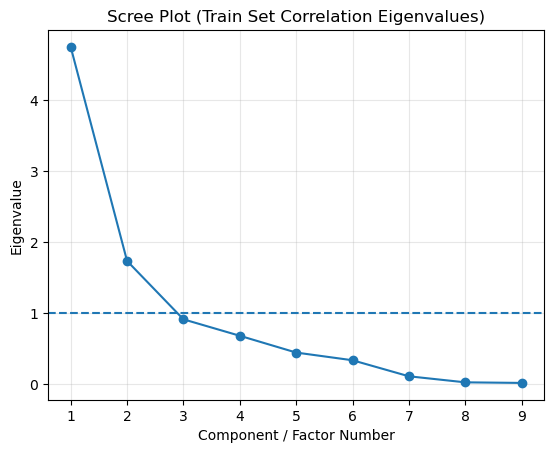

In [ ]:
###Scree plot + Kaiser line (eigenvalue = 1)

x = np.arange(1, len(eigenvalues) + 1)

plt.plot(x, eigenvalues, marker="o")
plt.axhline(1.0, linestyle="--")  # Kaiser criterion threshold
plt.title("Scree Plot (Train Set Correlation Eigenvalues)")
plt.xlabel("Component / Factor Number")
plt.ylabel("Eigenvalue")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.show()

#### Parallel Analysis
Parallel analysis compares your eigenvalues to what you’d expect from random noise with the same shape.

**Rule:** keep factors where actual_eigs > random_95%_eigs.

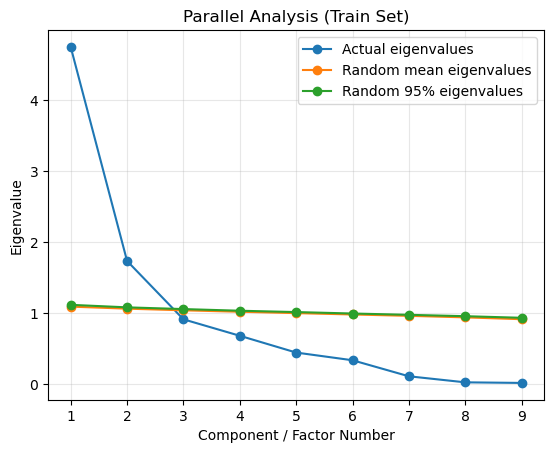

Parallel analysis suggests factors = 2


In [ ]:
import numpy as np

def parallel_analysis_eigenvalues(X, n_iter=500, random_state=42):
    """
    X: standardized train data as DataFrame or ndarray (n_samples x n_features)
    Returns:
      actual_eigs: eigenvalues from real data correlation
      rand_mean_eigs: mean eigenvalues from random data correlation
      rand_p95_eigs: 95th percentile eigenvalues from random data correlation
    """
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    n, p = X.shape

    # Actual eigenvalues from correlation matrix
    corr = np.corrcoef(X, rowvar=False)
    actual_eigs = np.linalg.eigvalsh(corr)[::-1]

    rand_eigs = np.zeros((n_iter, p))
    for i in range(n_iter):
        Z = rng.standard_normal((n, p))
        corr_z = np.corrcoef(Z, rowvar=False)
        rand_eigs[i, :] = np.linalg.eigvalsh(corr_z)[::-1]

    rand_mean_eigs = rand_eigs.mean(axis=0)
    rand_p95_eigs = np.quantile(rand_eigs, 0.95, axis=0)
    return actual_eigs, rand_mean_eigs, rand_p95_eigs

actual_eigs, rand_mean_eigs, rand_p95_eigs = parallel_analysis_eigenvalues(X_train, n_iter=300)

x = np.arange(1, len(actual_eigs) + 1)
plt.plot(x, actual_eigs, marker="o", label="Actual eigenvalues")
plt.plot(x, rand_mean_eigs, marker="o", label="Random mean eigenvalues")
plt.plot(x, rand_p95_eigs, marker="o", label="Random 95% eigenvalues")
plt.title("Parallel Analysis (Train Set)")
plt.xlabel("Component / Factor Number")
plt.ylabel("Eigenvalue")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

k_parallel = int((actual_eigs > rand_p95_eigs).sum())
print("Parallel analysis suggests factors =", k_parallel)

<b><u>Final Choice of Number of Factors</u></b>

Although both the Kaiser criterion and parallel analysis suggest retaining two statistically dominant factors, we ultimately select **three factors** for this project based on a balance between statistical evidence and economic interpretability. 

* In yield-curve analysis, extensive empirical literature (e.g., Litterman & Scheinkman, 1991) shows that Treasury yield movements are consisted of three economically meaningful components: **Level, Slope, and Curvature**. While the third factor explains less incremental variance than the first two, it captures curvature dynamics (belly-versus-wings movements) that are important for risk decomposition, scenario design, and fixed-income portfolio management. 
* According to statistical evaluations above, although the third factor is not strictly statistical significant, it is very close to significance level.

Therefore, retaining three factors improves interpretability and business relevance without materially increasing model complexity and heavily breaking statistical judgement, and aligns the analysis with established term-structure modeling practice.

### 8. FA Model Fit & Results (Training Dataset)

<b><u>Why we use Varimax rotation (interpretability)</u></b>

Varimax is an orthogonal rotation that maximizes the spread of squared loadings, making each factor load strongly on some maturities and weakly on others → easier interpretation.

In this project, varimax helps separate common yield-curve movement patterns into clearer components by reducing “mixed” loadings across maturities. We prefer orthogonal rotation here because it keeps factors approximately uncorrelated, which simplifies downstream risk attribution and regime analysis.

#### 8.1 Factor loadings

In [ ]:
###Fit the FactorAnalyzer (3 factors, ML, varimax)
n_factors = 3

fa = FactorAnalyzer(
    n_factors=n_factors,
    rotation="varimax",
    method="ml"
)

fa.fit(X_train)
print("Factor model fitted.")

Factor model fitted.


In [ ]:
###Extract and display factor loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=X_train.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Factor Loadings on Training Data")
loadings

Factor Loadings on Training Data


,Factor1,Factor2,Factor3
DGS1MO,0.009840,0.309245,-0.007502
DGS3MO,0.032143,0.579266,0.080704
DGS6MO,0.093272,0.758911,0.199434
DGS1,0.232652,0.557343,0.409012
DGS2,0.448955,0.296216,0.682692
DGS5,0.712690,0.110491,0.689115
DGS10,0.895449,0.093331,0.404291
DGS20,0.971813,0.098162,0.201924
DGS30,0.970945,0.098050,0.139347


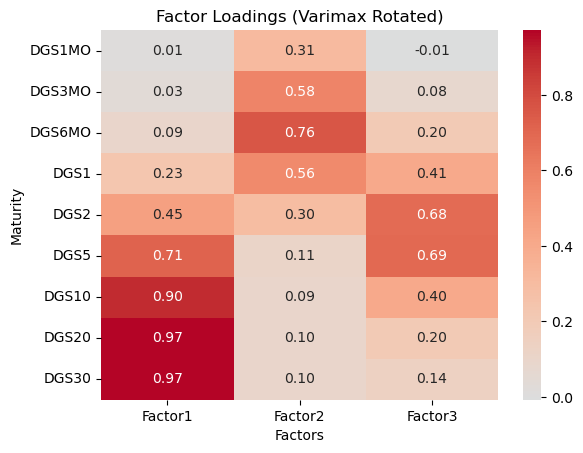

In [ ]:
###Plot loading heatmap
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Factor Loadings (Varimax Rotated)")
plt.xlabel("Factors")
plt.ylabel("Maturity")
plt.show()

<b><u>Interpretation of Each Factors:</u></b> A loading tells us how strongly each maturity is associated with a latent factor

They are not perfectly the textbook Level / Slope / Curvature trio, since **Varimax rotation changes the factor structure**. It makes each maturity load strongly on fewer factors and **prioritizes interpretability**, but not necessarily textbook shapes.

**But they are still economically meaningful and gives a more sample-specific structure:**
* Factor 1 – Long-End Factor: Loadings increase steadily from near zero at the short end (1M–6M) to very high values at the long end (10Y–30Y), indicating that this factor primarily captures movements in medium-to-long maturity yields, reflecting shifts in long-term rate expectations or term-premium dynamics.
* Factor 2 – Front-End / Policy Factor: Loadings are strongest for short maturities (1M–1Y) and decline sharply toward the long end (10Y–30Y), suggesting that this factor represents short-end yield movements driven by near-term monetary policy expectations.
* Factor 3 – Curvature / Belly Factor: Loadings peak in the intermediate maturities (especially 2Y–5Y) while remaining weaker at both the short and long ends, indicating that this factor captures belly-of-the-curve movements associated with yield-curve curvature dynamics.

**Overall, the factor structure suggests that Treasury yield changes in the training period are driven by distinct front-end, long-end, and intermediate-maturity dynamics rather than a perfectly uniform textbook level–slope–curvature decomposition.**


#### 8.2 Variance explained by each factor

In [ ]:
###Variance explained by each factor
# factor_analyzer returns: (SS loadings, proportion variance, cumulative variance)
ss_loadings, prop_var, cum_var = fa.get_factor_variance()

var_table = pd.DataFrame({
    "SS Loadings": ss_loadings,
    "Proportion Var": prop_var,
    "Cumulative Var": cum_var
}, index=[f"Factor{i+1}" for i in range(n_factors)])

var_table

,SS Loadings,Proportion Var,Cumulative Var
Factor1,3.462428,0.384714,0.384714
Factor2,1.445671,0.160630,0.545344
Factor3,1.378224,0.153136,0.698480


<b><u>Interpretation:</b></u>

* Factor 1 explains 38.5% of variance, making it the dominant common driver of Treasury yield changes in the training period and suggesting that long-end co-movement is the primary source of systematic variation.

* Factor 2 and Factor 3 explain 16.1% and 15.3%, respectively, indicating that short-end policy-sensitive movements and intermediate-maturity curvature dynamics also contribute meaningfully to yield curve variation.

* The three-factor model explains 69.8% cumulatively, showing that a small number of latent factors capture most of the shared covariance across maturities, while the remaining variation is treated as residual or idiosyncratic noise.

#### 8.3 Factor scores / factor shocks on the training set

In [ ]:
### Compute Factor shocks (factor scores) for train 

F_train = pd.DataFrame(
    fa.transform(X_train),
    index=X_train.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

F_train.head()

,Factor1,Factor2,Factor3
Date,,,
2010-01-05,-0.774537,-0.914163,-1.888034
2010-01-06,2.235004,-1.094393,-0.852421
2010-01-07,-0.385771,-0.027455,1.026399
2010-01-08,0.313009,-0.745353,-1.774737
2010-01-11,0.866794,-1.240324,-0.387152


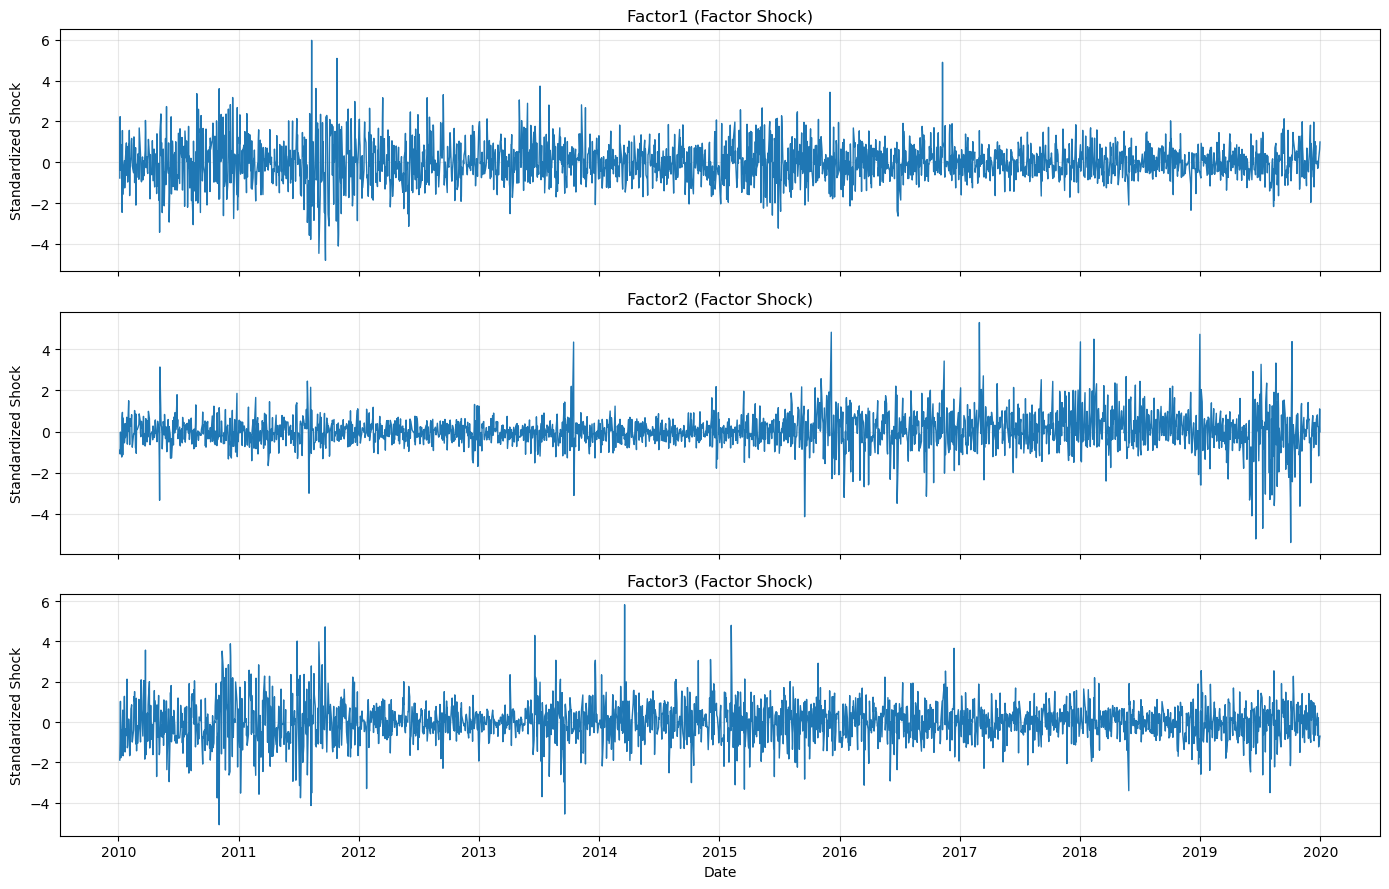

In [ ]:
###Plot factor scores over time (train)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for i, col in enumerate(F_train.columns):
    axes[i].plot(F_train.index, F_train[col], linewidth=1)
    axes[i].set_title(f"{col} (Factor Shock)")
    axes[i].set_ylabel("Standardized Shock")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

**Simple Insights:**
* positive factor score = above-average systematic shock on that day
* negative factor score = below-average systematic shock on that day
* near zero = relatively normal day with little common shock

<b><u>Interpretation:</b></u>

* All three factor shock series are centered around zero, which is consistent with the use of standardized daily yield changes as model input. Positive and negative values therefore represent above- and below-average systematic rate shocks rather than long-run trends in yields.

* Factor 1 shows the largest and most persistent swings over the training period, suggesting that long-end Treasury movements were the dominant source of common variation from 2010 to 2019. Several large spikes indicate episodes of substantial systematic shocks affecting medium- to long-maturity yields.

* Factor 2 becomes visibly more volatile in the later part of the sample, especially around 2016–2019, implying that front-end or policy-sensitive yield dynamics became more active as the market increasingly reacted to monetary policy normalization and shifting rate expectations.

* Factor 3 exhibits intermittent bursts of volatility rather than a sustained trend, which is consistent with a curvature/belly factor that becomes important during specific episodes when intermediate maturities move differently from the short and long ends.

<b><u>Even within the training window (2010–2019), factor volatility varies meaningfully over time. This indicates that the intensity of systematic yield shocks changes across periods, providing motivation for later regime clustering and tail/anomaly detection.</b></u>



#### 8.4 Reconstruction quality on the training set

In [ ]:
### Reconstruct the training data

# Loadings matrix
Lambda = fa.loadings_   # shape: (n_maturities, n_factors)

# Reconstruct standardized training data
Xhat_train = F_train.values @ Lambda.T

# Convert to DataFrame for readability
Xhat_train = pd.DataFrame(
    Xhat_train,
    index=X_train.index,
    columns=X_train.columns
)

Xhat_train.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS20,DGS30
Date,,,,,,,,,
2010-01-05,-0.276158,-0.706811,-1.142550,-1.461928,-1.907466,-1.954084,-1.542193,-1.223680,-1.104759
2010-01-06,-0.310048,-0.630900,-0.792086,-0.438625,0.097299,0.884529,1.554565,1.892454,1.943980
2010-01-07,-0.019987,0.054531,0.147882,0.314758,0.519388,0.429339,0.066964,-0.170338,-0.234228
2010-01-08,-0.214102,-0.564924,-0.890405,-1.068484,-1.291856,-1.082274,-0.506791,-0.127340,-0.016471
2010-01-11,-0.372130,-0.721861,-0.937660,-0.647974,-0.242557,0.213919,0.503888,0.642434,0.666048


In [ ]:
### Compute reconstruction error

# Reconstruction residuals
residual_train = X_train - Xhat_train

# Overall RMSE
rmse_train = np.sqrt(np.mean((residual_train.values) ** 2))
print(f"RMSE (Train, standardized units): {rmse_train:.4f}")

RMSE (Train, standardized units): 0.5119


In [ ]:
### RMSE by maturity

rmse_by_maturity_train = pd.Series(
    np.sqrt(np.mean((residual_train.values) ** 2, axis=0)),
    index=X_train.columns,
    name="RMSE_train"
).sort_values(ascending=False)

rmse_by_maturity_train

DGS1MO    0.937475
DGS3MO    0.755583
DGS1      0.631813
DGS6MO    0.482264
DGS2      0.477925
DGS10     0.153848
DGS30     0.153380
DGS20     0.035116
DGS5      0.018404
Name: RMSE_train, dtype: float64

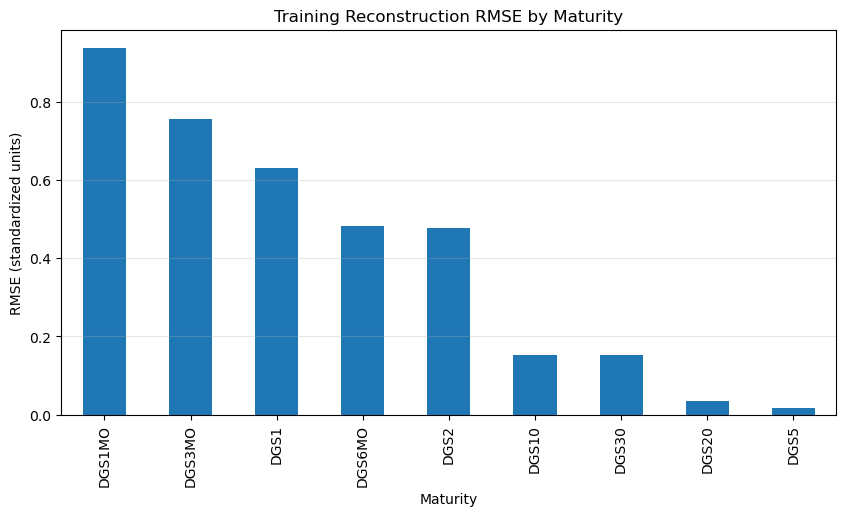

In [ ]:
### Plot RMSE by maturity
plt.figure(figsize=(10, 5))
rmse_by_maturity_train.plot(kind="bar")
plt.title("Training Reconstruction RMSE by Maturity")
plt.xlabel("Maturity")
plt.ylabel("RMSE (standardized units)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

<b><u>Interpretation:</b></u>

* **Overall reconstruction quality (RMSE = 0.5119):** Because the inputs are standardized, an RMSE of 1 would correspond roughly to a model that explains almost none of the variation, while an RMSE of 0 would imply perfect reconstruction. In Factor Analysis, however, perfect reconstruction is not a realistic target because the model explicitly allows an idiosyncratic error term ϵ, meaning part of the variation is intentionally left unexplained. Against this benchmark, an in-sample RMSE of 0.5119 indicates that the three-factor model captures a substantial share of the common yield-curve movement while still leaving meaningful residual variation.

* **Cross-maturity pattern:** Reconstruction quality is not uniform across the curve. Errors are highest for the front-end maturities (especially 1M, 3M, and 1Y), moderate for 6M and 2Y, and very low for the belly and long end (5Y, 10Y, 20Y, 30Y). This indicates that the estimated factors explain intermediate- and long-maturity co-movement particularly well, while short-end yields retain more variation outside the common factor structure.

* **Why the front end fits worse, and why that is reasonable:** The short end of the Treasury curve is more directly affected by near-term monetary policy expectations, meeting-to-meeting repricing, and money-market or liquidity effects, which can create more localized and abrupt movements. By contrast, the belly and long end tend to move more smoothly with broad systematic forces such as medium-term rate expectations and term-premium dynamics. It is therefore economically reasonable that a parsimonious three-factor model fits the intermediate and long maturities better than the very short end.

**The belly and long end are more consistently explained by broad systematic factors, while the front end retains more localized, policy-sensitive variation.**

<b><u>Possible ways to improve the fit:</b></u>

* Add one more factor
* Model the front end separately
* Use lower-frequency changes
* Add observable macro/policy variables
* Rolling or regime-specific estimation


### 9. Out-of-sample Model Validation of FA (Test Set)

To evaluate structural stability, we apply the factor model estimated on the 2010–2019 training period to the 2020–2024 test period. Specifically, we project the standardized test yield changes onto the trained factor structure, reconstruct the implied yield changes, and compare them with the observed inputs. The resulting reconstruction error measures whether the pre-2020 latent factor structure remains adequate under materially different market conditions, including the COVID shock, inflation surge, and aggressive tightening cycle.

In [ ]:
### Compute factor scores for the test set

# Factor shocks (factor scores) for test set
F_test = pd.DataFrame(
    fa.transform(X_test),
    index=X_test.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

F_test.head()

,Factor1,Factor2,Factor3
Date,,,
2020-01-02,-1.228383,-1.508475,0.884493
2020-01-03,-1.319076,-0.884458,-0.991912
2020-01-06,0.311351,0.716444,0.168078
2020-01-07,0.758517,-0.537590,-0.370048
2020-01-08,0.854145,0.098219,0.678362


In [ ]:
### Reconstruct the test set

# Reconstruct standardized test data
Xhat_test = F_test.values @ Lambda.T

Xhat_test = pd.DataFrame(
    Xhat_test,
    index=X_test.index,
    columns=X_test.columns
)

Xhat_test.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS20,DGS30
Date,,,,,,,,,
2020-01-02,-0.485212,-0.841911,-1.082974,-0.764754,-0.394486,-0.432612,-0.883148,-1.163234,-1.217347
2020-01-03,-0.279053,-0.634786,-0.992079,-1.205535,-1.531366,-1.721359,-1.664733,-1.569006,-1.505692
2020-01-06,0.223360,0.438584,0.606278,0.540487,0.466750,0.416883,0.413618,0.406842,0.395973
2020-01-07,-0.156007,-0.316891,-0.411035,-0.274505,-0.071331,0.226183,0.479432,0.609644,0.632203
2020-01-08,0.033689,0.139096,0.289496,0.530918,0.875679,1.087063,1.048266,0.976688,0.933487


In [ ]:
### Compute residuals and overall RMSE on the test set
# Test residuals
residual_test = X_test - Xhat_test

# Overall RMSE
rmse_test = np.sqrt(np.mean((residual_test.values) ** 2))
print(f"RMSE (Test, standardized units): {rmse_test:.4f}")

RMSE (Test, standardized units): 1.1818


<b><u>Interpretation:</b></u>

* **The overall test RMSE increases from 0.5119 in the training period to 1.1818 in the test period,** indicating that the factor structure estimated from 2010–2019 does not reconstruct post-2020 yield changes as well as it reconstructs the pre-2020 sample.

* **Because the inputs are standardized, an RMSE near 1 corresponds roughly to a weak reconstruction benchmark,** so a test RMSE above 1 suggests that the pre-2020 latent factor structure loses substantial explanatory power in the 2020–2024 environment.

* **This result does not mean the factor model is useless; rather, it suggests that Treasury yield dynamics changed materially since 2020,** which is consistent with the presence of major stress events such as the COVID shock, inflation surge, and aggressive monetary tightening cycle.

In [ ]:
### RMSE by maturity on the test set
rmse_by_maturity_test = pd.Series(
    np.sqrt(np.mean((residual_test.values) ** 2, axis=0)),
    index=X_test.columns,
    name="RMSE_test"
).sort_values(ascending=False)

rmse_by_maturity_test

DGS1MO    2.570683
DGS3MO    1.559187
DGS1      1.461907
DGS6MO    0.840118
DGS2      0.782799
DGS30     0.196346
DGS10     0.181637
DGS20     0.048199
DGS5      0.022608
Name: RMSE_test, dtype: float64

In [ ]:
### Compare train vs test by maturity
rmse_compare = pd.concat(
    [rmse_by_maturity_train, rmse_by_maturity_test],
    axis=1
)

rmse_compare["Increase"] = rmse_compare["RMSE_test"] - rmse_compare["RMSE_train"]
rmse_compare = rmse_compare.sort_values("RMSE_test", ascending=False)

rmse_compare

,RMSE_train,RMSE_test,Increase
DGS1MO,0.937475,2.570683,1.633208
DGS3MO,0.755583,1.559187,0.803604
DGS1,0.631813,1.461907,0.830095
DGS6MO,0.482264,0.840118,0.357854
DGS2,0.477925,0.782799,0.304874
DGS30,0.153380,0.196346,0.042966
DGS10,0.153848,0.181637,0.027788
DGS20,0.035116,0.048199,0.013082
DGS5,0.018404,0.022608,0.004205


<b><u>Interpretation:</b></u>

* **The largest increase occurs in DGS1MO (+1.633), followed by DGS1 and DGS3MO,** showing that the model’s loss of explanatory power is overwhelmingly driven by front-end maturities.

* **The increases for 10Y, 20Y, 30Y, and especially 5Y are very small,** suggesting that the medium- and long-end factor structure learned from the training set remains broadly stable even in the test period.

**This asymmetric increase across maturities provides strong evidence that the main structural instability after 2020 is concentrated in short-rate dynamics rather than in the entire yield curve.**

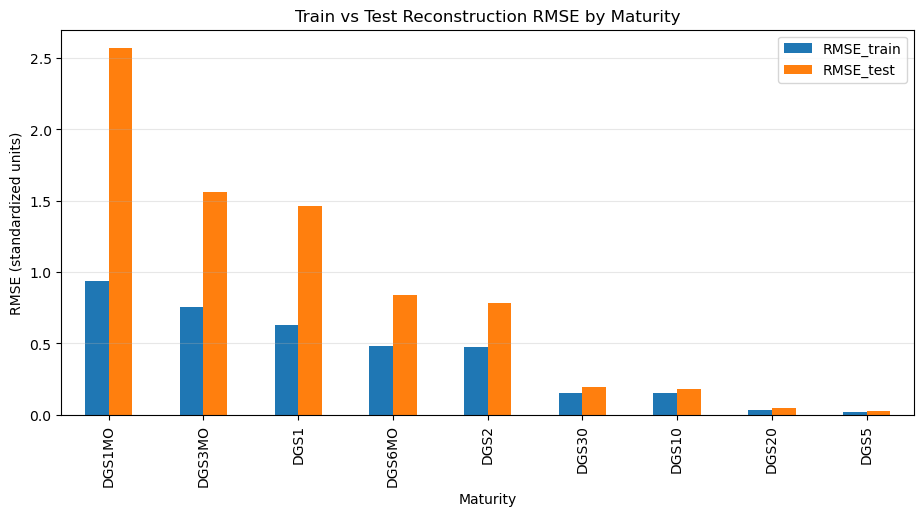

In [ ]:
### Plot train vs test RMSE by maturity
rmse_compare[["RMSE_train", "RMSE_test"]].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Train vs Test Reconstruction RMSE by Maturity")
plt.xlabel("Maturity")
plt.ylabel("RMSE (standardized units)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

<b><u>Interpretation:</b></u>

* **The deterioration in reconstruction quality is highly concentrated at the front end of the curve,** especially for 1M, 3M, and 1Y maturities, where the test RMSE rises sharply relative to the training period.

* **Intermediate and long maturities remain much better explained,** with only modest increases in RMSE for 5Y, 10Y, 20Y, and 30Y. This indicates that the factor structure remains more stable for the belly and long end than for the very short end.

**The maturity pattern is therefore not uniform:** the model continues to capture medium- and long-term co-movement reasonably well, but struggles to generalize short-end dynamics from the pre-2020 regime to the post-2020 regime.

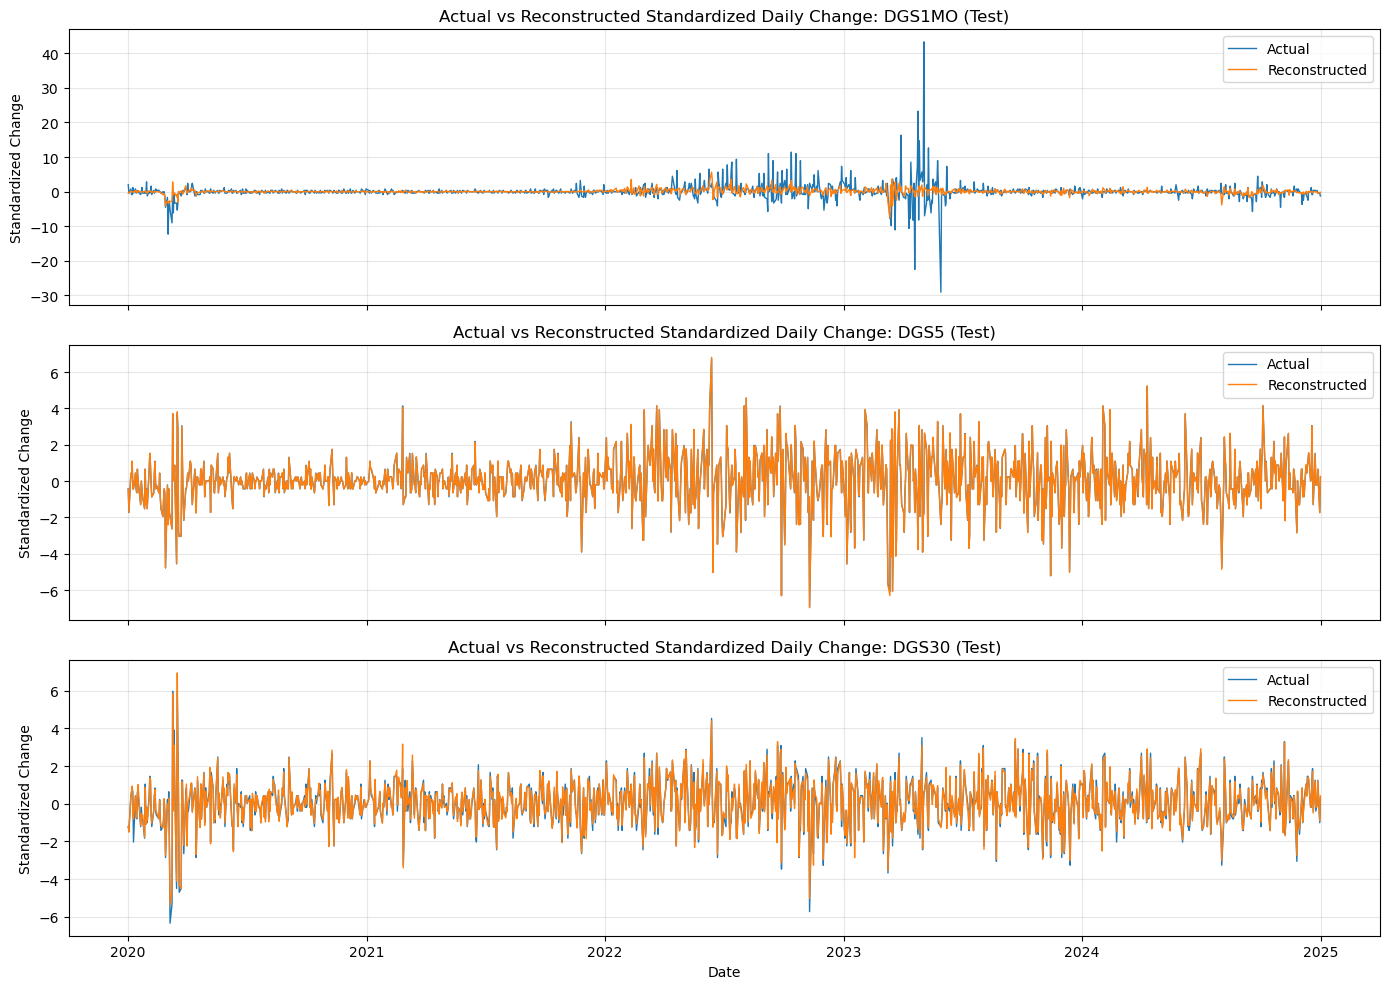

In [ ]:
### Plot actual vs reconstructed on test period for selected maturities

selected_maturities = ["DGS1MO", "DGS5", "DGS30"]

fig, axes = plt.subplots(len(selected_maturities), 1, figsize=(14, 10), sharex=True)

for i, maturity in enumerate(selected_maturities):
    axes[i].plot(X_test.index, X_test[maturity], label="Actual", linewidth=1)
    axes[i].plot(Xhat_test.index, Xhat_test[maturity], label="Reconstructed", linewidth=1)
    axes[i].set_title(f"Actual vs Reconstructed Standardized Daily Change: {maturity} (Test)")
    axes[i].set_ylabel("Standardized Change")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### 10. Regime Clustering (Agglomerative Clustering)

The factor analysis results reveal that a small number of latent factors capture the common movements of Treasury yields across maturities. However, the dynamics of these factor shocks are not constant over time. The factor shock series exhibit periods of higher and lower volatility, and the out-of-sample validation shows that the factor structure estimated from the 2010–2019 training period reconstructs the 2020–2024 period substantially worse, especially at the front end of the yield curve. 

These findings suggest that Treasury market dynamics may differ across distinct market environments. In particular, major macro-financial events such as the COVID shock, the inflation surge, and the aggressive monetary tightening cycle after 2021 may correspond to different systematic shock patterns than those observed during the earlier, relatively stable period.

To better understand these time-varying dynamics, we apply regime clustering to the factor-shock space. By grouping days with similar combinations of factor shocks, clustering allows us to identify distinct market states characterized by different patterns of systematic yield-curve movements. This provides a data-driven way to segment market behavior into regimes that can be useful for risk monitoring and market interpretation.

#### 10.1 Model Design 

<b><u>Choice of Agglomerative Clustering</u></b>

We use agglomerative hierarchical clustering to identify regimes in the factor-shock space. Agglomerative clustering is a bottom-up hierarchical method that iteratively merges observations based on their similarity. This approach is well suited for our application because it does not require strong assumptions about the distribution of clusters and works effectively in low-dimensional continuous feature spaces such as the three-factor shock representation. In addition, hierarchical clustering is widely used in exploratory data analysis when the objective is to discover natural groupings in the data rather than to impose a predefined structure.

<b><u>Choice of Number of Clusters</u></b>

We set the number of clusters to 4 in order to balance interpretability and flexibility. A small number of clusters helps maintain clear economic interpretation of the regimes, while still allowing the model to distinguish between different types of market conditions. In the context of interest-rate markets, a four-regime segmentation can typically capture states such as calm markets, moderate volatility environments, and stress periods characterized by large systematic shocks.

<b><u>Choice of Ward Linkage</u></b>

We use Ward linkage as the merging criterion. Ward linkage minimizes the increase in within-cluster variance at each step of the clustering process, which tends to produce compact and well-separated clusters. This property is particularly desirable when clustering continuous factor shocks, because it groups together days with similar magnitudes and combinations of systematic yield-curve movements.

#### 10.2 Model Fit & Results

In [ ]:
### Build full factor-score dataset
# Combine train and test factor shocks
F_all = pd.concat([F_train, F_test], axis=0).sort_index()

print(F_all.shape)
F_all.head()

(3751, 3)


,Factor1,Factor2,Factor3
Date,,,
2010-01-05,-0.774537,-0.914163,-1.888034
2010-01-06,2.235004,-1.094393,-0.852421
2010-01-07,-0.385771,-0.027455,1.026399
2010-01-08,0.313009,-0.745353,-1.774737
2010-01-11,0.866794,-1.240324,-0.387152


In [ ]:
### Fit Agglomerative Clustering

n_clusters = 4

cluster_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

cluster_labels = cluster_model.fit_predict(F_all)

# Add regime labels to dataframe
F_all_clustered = F_all.copy()
F_all_clustered["Regime"] = cluster_labels

F_all_clustered.head()

,Factor1,Factor2,Factor3,Regime
Date,,,,
2010-01-05,-0.774537,-0.914163,-1.888034,0
2010-01-06,2.235004,-1.094393,-0.852421,1
2010-01-07,-0.385771,-0.027455,1.026399,2
2010-01-08,0.313009,-0.745353,-1.774737,0
2010-01-11,0.866794,-1.240324,-0.387152,1


In [ ]:
### Cluster summary table
cluster_summary = F_all_clustered.groupby("Regime")[["Factor1", "Factor2", "Factor3"]].mean()
cluster_summary

,Factor1,Factor2,Factor3
Regime,,,
0,-0.391076,-1.963333,-1.159417
1,1.214869,-0.192756,-0.080556
2,-0.336223,0.252415,0.189610
3,0.387472,4.908170,1.267014


<b><u>Cluster Summary Table (Mean factor shocks by regime)</u></b>

* **Regime 2 (Baseline / Normal Market Regime) shows relatively small average factor shocks across all three factors,** indicating typical market conditions with moderate systematic movements.

* **Regime 1 (Long-End Dominant Regime) is characterized by a strong positive Factor1 shock,** suggesting periods dominated by movements associated with the long-end factor of the yield curve.

* **Regime 0 (Front-End / Downward Curvature Shock Regime) exhibits large negative Factor2 and Factor3 shocks,** implying episodes where front-end or curvature-related movements dominate the yield curve dynamics.

* **Regime 3 (High-Stress / Extreme Shock Regime) displays extremely large positive Factor2 and Factor3 shocks,** indicating rare but intense episodes where front-end and curvature factors experience unusually strong movements.

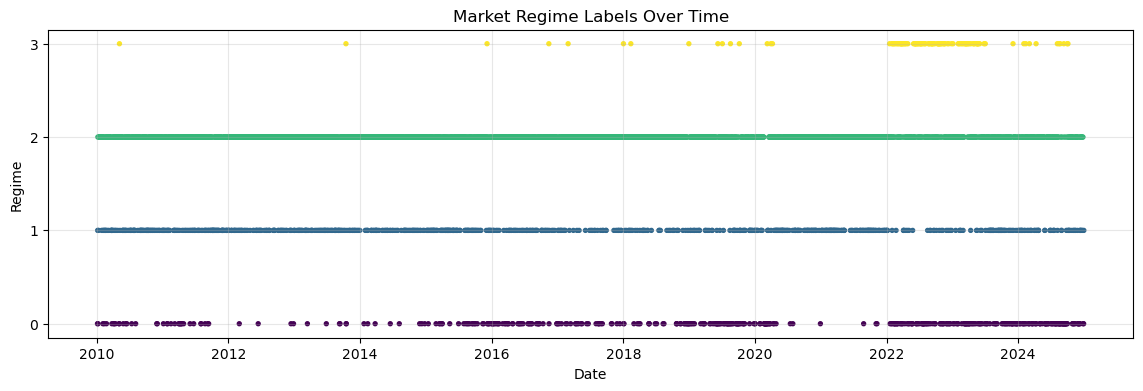

In [ ]:
### Plot regime labels over time
plt.figure(figsize=(14, 4))
plt.scatter(F_all_clustered.index, F_all_clustered["Regime"], 
            c=F_all_clustered["Regime"], s=8)
plt.title("Market Regime Labels Over Time")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.yticks(range(n_clusters))
plt.grid(True, alpha=0.3)
plt.show()

<b><u>Market Regime Labels Over Time (Time-series plot)</u></b>

* **Regime 2 dominates the sample,** indicating that most days fall into a relatively stable baseline market state with moderate factor movements. 

* **Regime 0 and Regime 1 appear intermittently,** suggesting transitional market conditions where certain systematic shocks become more pronounced but not extreme.

* **Regime 3 occurs infrequently but appears clustered in specific periods,** which likely correspond to episodes of elevated market stress or unusually large systematic shocks.

* **The concentration of Regime 3 observations increases in the later part of the sample,** consistent with the more volatile macro-financial environment following the COVID shock and the subsequent monetary tightening cycle.

In [ ]:
cluster_sizes = F_all_clustered["Regime"].value_counts().sort_index()
cluster_sizes

Regime
0     441
1     816
2    2382
3     112
Name: count, dtype: int64

<b><u>Cluster Size Table (Number of observations in each regime)</u></b>

* **Regime 2 contains the majority of observations (2382 days),** confirming that most of the sample corresponds to relatively normal market conditions.

* **Regime 1 and Regime 0 represent moderate-frequency regimes,** capturing transitional states where one or more systematic factors temporarily dominate.

* **Regime 3 is the smallest cluster (112 observations),** suggesting that extreme factor shock combinations occur relatively rarely and may correspond to stress periods.

* This distribution is consistent with financial markets, where calm regimes are most common and stress regimes occur only intermittently.

In [ ]:
### Factor volatility by regime
cluster_vol = F_all_clustered.groupby("Regime")[["Factor1", "Factor2", "Factor3"]].std()
cluster_vol

,Factor1,Factor2,Factor3
Regime,,,
0,0.956027,2.227729,1.441163
1,0.753036,0.583452,1.045640
2,0.805585,0.717989,0.989531
3,1.096410,2.571475,1.848631


<b><u>Factor Volatility by Regime</u></b>

* **Regime 3 shows the highest volatility across all three factors,** indicating that this regime corresponds to periods of elevated systemic interest-rate shocks.

* **Regime 0 also exhibits relatively high volatility,** particularly in Factor2, suggesting that this regime reflects periods of strong front-end or policy-driven movements.

* **Regimes 1 and 2 display lower factor volatility,** indicating more stable market environments with smaller systematic rate shocks.

* **The clear volatility differences across regimes confirm that clustering successfully separates calm and stressed market states,** supporting the interpretation of the clusters as distinct market regimes.

In [ ]:
### Visualize regimes in factor space
import plotly.express as px

# Make regime a string for cleaner legend display
F_all_clustered["Regime"] = F_all_clustered["Regime"].astype(str)

fig = px.scatter_3d(
    F_all_clustered,
    x="Factor1",
    y="Factor2",
    z="Factor3",
    color="Regime",
    hover_data={"Regime": True},
    title="Interactive 3D Regime Clustering in Factor-Shock Space",
    opacity=0.7
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(
        xaxis_title="Factor1",
        yaxis_title="Factor2",
        zaxis_title="Factor3"
    ),
    legend_title="Regime",
    width=900,
    height=700
)

fig.show()

### 11. Anomaly Detection (Isolation Forest) -- 2% Extreme Events
The regime clustering analysis shows that Treasury market dynamics can be segmented into several distinct states characterized by different combinations of systematic factor shocks. While clustering identifies broad market regimes, it does not specifically isolate the most extreme observations within those regimes.

In financial markets, rare but large movements in systematic risk factors are particularly important for risk monitoring because they correspond to tail events, such as abrupt monetary-policy repricing, liquidity shocks, or macroeconomic surprises. These events may occur within otherwise normal regimes and therefore may not be captured solely by regime segmentation.

To identify such extreme observations, we apply anomaly detection to the factor-shock space. By detecting days where the combination of factor shocks deviates substantially from typical patterns, anomaly detection helps flag potential tail events in the Treasury market. This complements the regime clustering analysis by highlighting individual days with unusually large systematic shocks.

<b><u>Why Isolation Forest:</u></b>

We use the Isolation Forest algorithm to detect anomalies in the factor-shock space. Isolation Forest is an unsupervised method designed to identify rare observations that differ significantly from the bulk of the data. The algorithm works by recursively partitioning the feature space using random splits, with anomalous observations requiring fewer partitions to be isolated.

This approach is well suited for our application because it does not require labeled examples of anomalies and performs well in low-dimensional continuous spaces such as the three-factor shock representation. By applying Isolation Forest to the factor shocks, we can identify days where systematic yield-curve movements are unusually large relative to the historical distribution.

<b><u>We detect anomalies on:</u></b> F_all = [Factor1, Factor2, Factor3]

* these are the systematic shocks
* anomalies correspond to extreme systematic rate movements

In [ ]:
# Features used for anomaly detection
X_anomaly = F_all[["Factor1", "Factor2", "Factor3"]]

# Fit Isolation Forest
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # assume ~2% extreme events
    random_state=42
)

anomaly_labels = iso_model.fit_predict(X_anomaly)

# Convert labels
F_all_clustered["Anomaly"] = anomaly_labels
F_all_clustered["Anomaly"] = F_all_clustered["Anomaly"].map({1:0, -1:1})

F_all_clustered.head()

#0 = normal observation
#1 = anomaly (tail event)

,Factor1,Factor2,Factor3,Regime,Anomaly
Date,,,,,
2010-01-05,-0.774537,-0.914163,-1.888034,0,0
2010-01-06,2.235004,-1.094393,-0.852421,1,0
2010-01-07,-0.385771,-0.027455,1.026399,2,0
2010-01-08,0.313009,-0.745353,-1.774737,0,0
2010-01-11,0.866794,-1.240324,-0.387152,1,0


In [ ]:
###Count anomalies
F_all_clustered["Anomaly"].value_counts()

Anomaly
0    3676
1      75
Name: count, dtype: int64

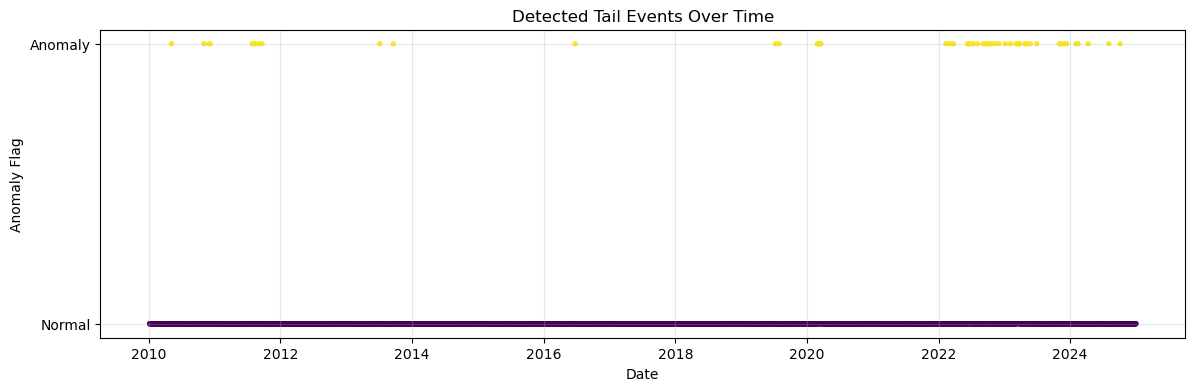

In [ ]:
###Plot anomalies over time

plt.figure(figsize=(14,4))

plt.scatter(
    F_all_clustered.index,
    F_all_clustered["Anomaly"],
    c=F_all_clustered["Anomaly"],
    s=8
)

plt.title("Detected Tail Events Over Time")
plt.xlabel("Date")
plt.ylabel("Anomaly Flag")
plt.yticks([0,1], ["Normal","Anomaly"])
plt.grid(True, alpha=0.3)

plt.show()

<b><u>Detected Tail Events Over Time:</u></b>

* Tail events are rare and clustered in time, with most observations classified as normal, confirming that the anomaly detector is capturing extreme market shocks rather than routine fluctuations.

* Clear concentration of anomalies appears during known stress periods, especially around 2020 (COVID shock) and 2022–2023 (inflation surge and aggressive monetary tightening).

* Earlier scattered anomalies (2010–2014) likely correspond to post-financial-crisis policy adjustments and rate-normalization episodes.

* The clustering of anomalies in macro stress periods indicates that extreme yield-curve movements are driven by large systematic factor shocks rather than random noise.

In [ ]:
### Check which regimes contain anomalies
pd.crosstab(
    F_all_clustered["Regime"],
    F_all_clustered["Anomaly"]
)

Anomaly,0,1
Regime,,
0,411,30
1,808,8
2,2374,8
3,83,29


<b><u>Regime vs Anomaly Crosstab:</u></b>

* Anomalies are highly concentrated in Regime 0 and Regime 3, suggesting these regimes correspond to market stress environments with unusually large factor shocks.

* Regime 2 contains the majority of observations but almost no anomalies, indicating it represents the typical stable market regime.

* Regime 1 also shows very few anomalies, suggesting a moderate but stable yield-curve environment.

* This pattern confirms that regime clustering captures different volatility structures, while anomaly detection isolates the most extreme realizations within those regimes.

In [ ]:
###normal vs anomaly
# Create readable anomaly label
F_all_clustered["Anomaly_Label"] = F_all_clustered["Anomaly"].map({0: "Normal", 1: "Anomaly"})

# Summary statistics by anomaly status
anomaly_summary = F_all_clustered.groupby("Anomaly_Label")[["Factor1", "Factor2", "Factor3"]].agg(["mean", "std", "min", "max"])

anomaly_summary

Factor1                                 Factor2            \
                   mean       std       min       max      mean       std   
Anomaly_Label                                                               
Anomaly        0.000620  2.495079 -5.146243  7.698702  0.105841  7.485803   
Normal         0.016685  0.995105 -4.808456  5.091587  0.032620  1.148919   

                                      Factor3                                
                     min        max      mean       std       min       max  
Anomaly_Label                                                                
Anomaly       -24.945705  18.337261 -0.505892  3.928790 -8.609847  5.220602  
Normal        -10.896282  11.600446  0.014816  1.071208 -5.674359  5.821225

<b><u>Factor Shock Comparison: Normal vs Anomaly Days:</u></b>

* Factor volatility increases dramatically during anomaly days, particularly for Factor2, whose standard deviation jumps from 1.15 to 7.49, indicating that slope shocks dominate extreme yield-curve movements.

* Extreme values are substantially larger during anomalies, especially for Factor2, which reaches −24.95 and +18.34, far exceeding normal market fluctuations.

* Factor3 volatility also rises significantly, suggesting that curvature distortions in the middle of the yield curve often accompany stress events.

* Factor1 shows a smaller relative increase, indicating that tail events are more strongly associated with changes in the curve shape (slope/curvature) than uniform level shifts.

* Overall, the results suggest that major market shocks tend to distort the structure of the yield curve rather than simply shifting it upward or downward uniformly.

In [ ]:
###Visualize anomalies in factor space

import plotly.express as px

plot_df = F_all_clustered.reset_index().rename(columns={"index": "Date"})

plot_df["Anomaly_Label"] = plot_df["Anomaly"].map({0: "Normal", 1: "Anomaly"})

fig = px.scatter_3d(
    plot_df,
    x="Factor1",
    y="Factor2",
    z="Factor3",
    color="Anomaly_Label",
    hover_data=["Date", "Regime"],
    title="Interactive 3D Tail Event Detection in Factor-Shock Space",
    opacity=0.7
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    scene=dict(
        xaxis_title="Factor1",
        yaxis_title="Factor2",
        zaxis_title="Factor3"
    ),
    legend_title="Observation Type",
    width=950,
    height=750
)

fig.show()

### 12. Conclusion

* Factor Analysis reduces nine correlated Treasury yield series into three interpretable systematic drivers, explaining ~70% of the covariance structure of daily yield changes.

* The extracted factors exhibit loading patterns consistent with the well-known Level, Slope, and Curvature structure of the yield curve, enabling clearer risk attribution across maturities.

* Agglomerative clustering applied to factor shocks reveals four distinct market regimes, representing different combinations of level shifts, curve steepening/flattening, and curvature changes.

* Isolation Forest anomaly detection identifies rare tail events where factor shocks become unusually large, with anomalies concentrated around major macroeconomic stress periods such as COVID-19 (2020) and the 2022–2023 inflation tightening cycle.

* Analysis of anomaly statistics shows that extreme market events are primarily driven by slope and curvature shocks, indicating that stress periods often involve structural distortions of the yield curve rather than uniform level shifts.

* Overall, the combined framework provides a practical market-risk monitoring tool that compresses complex yield movements into a small set of interpretable drivers while detecting regime shifts and tail events in interest-rate markets.

## System & Software Requirements: `factor_analyzer`

The `factor_analyzer` package is built on top of the standard Python scientific computing stack. Below are the specific requirements to ensure it runs smoothly in your environment.

### Operating System
* **Supported OS:** Cross-platform (Windows, macOS, and Linux/POSIX environments).

### Python Version
* **Required Version:** Python **3.8 or higher**. *(Note: Older versions of the package supported Python 3.6, but 3.8+ is required for the current 0.5.x releases).*

### Package Version
* **Latest Stable Release:** `factor-analyzer` 0.5.1 

### Required Dependencies
To use the package, you must have the following libraries installed. If you install via `pip`, these will generally be resolved and installed automatically:
* `numpy`
* `pandas`
* `scipy`
* `scikit-learn`

### Installation
You can install the package and its dependencies using pip:
`pip install factor-analyzer`

Alternatively, if you are using Conda:
`conda install -c ets factor_analyzer`

## App to Interact

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import ipywidgets as widgets

from factor_analyzer import FactorAnalyzer
from factor_analyzer.rotator import Rotator

from sklearn.preprocessing import StandardScaler

# -------------------------
# Helpers
# -------------------------
def _as_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    # keep only numeric columns, drop rows with any missing
    dfn = df.select_dtypes(include=[np.number]).copy()
    dfn = dfn.dropna(axis=0, how="any")
    return dfn

def _corr_heatmap(corr: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr.values)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def _barh(series: pd.Series, title: str):
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.35 * len(series))))
    ax.barh(series.index[::-1], series.values[::-1])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def _make_demo_data(n=600, seed=7):
    rng = np.random.default_rng(seed)
    # 3 latent factors (think: level/slope/curvature-ish) mixed into 9 observed vars
    F = rng.normal(size=(n, 3))
    load = np.array([
        [ 0.9,  0.2,  0.0],
        [ 0.9,  0.1,  0.0],
        [ 0.8,  0.0,  0.1],
        [ 0.7, -0.2,  0.2],
        [ 0.6, -0.4,  0.4],
        [ 0.5, -0.6,  0.6],
        [ 0.4, -0.7,  0.8],
        [ 0.3, -0.8,  0.9],
        [ 0.2, -0.9,  1.0],
    ])
    eps = rng.normal(scale=0.6, size=(n, 9))
    X = F @ load.T + eps
    cols = [f"var_{i+1}" for i in range(9)]
    return pd.DataFrame(X, columns=cols)

# -------------------------
# State
# -------------------------
DATA = _make_demo_data()

# -------------------------
# UI widgets
# -------------------------
title = widgets.HTML("<h3>Factor Analysis Interactive Demo</h3>")

data_source = widgets.Dropdown(
    options=[("Use built-in demo data", "demo")],
    value="demo",
    description="Data:",
    layout=widgets.Layout(width="350px")
)

upload = widgets.FileUpload(
    accept=".csv,.xlsx",
    multiple=False,
    description="Upload CSV/XLSX"
)

n_factors = widgets.IntSlider(
    value=3, min=1, max=8, step=1,
    description="# Factors",
    continuous_update=False
)

rotation = widgets.Dropdown(
    options=[("None", "none"), ("Varimax (orthogonal)", "varimax"), ("Promax (oblique)", "promax")],
    value="varimax",
    description="Rotation",
    layout=widgets.Layout(width="350px")
)

method = widgets.Dropdown(
    options=[("MinRes (recommended)", "minres"), ("ML (if approx normal)", "ml"), ("Principal", "principal")],
    value="minres",
    description="Method",
    layout=widgets.Layout(width="350px")
)

use_standardize = widgets.Checkbox(value=True, description="Standardize (z-score)")
show_corr = widgets.Checkbox(value=False, description="Show correlation heatmap")

run_btn = widgets.Button(description="Run Factor Analysis", button_style="primary")
out = widgets.Output()

var_select = widgets.SelectMultiple(
    options=list(DATA.columns),
    value=tuple(DATA.columns),
    description="Vars",
    layout=widgets.Layout(width="350px", height="160px")
)

# -------------------------
# Upload handler
# -------------------------
def _load_uploaded():
    if not upload.value:
        return None
    # ipywidgets FileUpload gives a dict of files
    info = list(upload.value.values())[0]
    name = info["metadata"]["name"]
    content = info["content"]
    if name.lower().endswith(".csv"):
        from io import BytesIO
        return pd.read_csv(BytesIO(content))
    if name.lower().endswith(".xlsx"):
        from io import BytesIO
        return pd.read_excel(BytesIO(content))
    raise ValueError("Unsupported file type. Please upload .csv or .xlsx")

def _refresh_var_options(df):
    var_select.options = list(df.columns)
    var_select.value = tuple(df.columns)

def _on_upload_change(change):
    df = _load_uploaded()
    if df is None:
        return
    dfn = _as_numeric_df(df)
    if dfn.shape[1] < 2:
        with out:
            clear_output()
            print("Uploaded data has <2 numeric columns after cleaning.")
        return
    global DATA
    DATA = dfn
    _refresh_var_options(DATA)
    # update factor slider max reasonably
    n_factors.max = min(12, max(2, DATA.shape[1] - 1))
    with out:
        clear_output()
        print(f"Loaded: {dfn.shape[0]} rows × {dfn.shape[1]} numeric columns (NA rows dropped).")

upload.observe(_on_upload_change, names="value")

# -------------------------
# Main run
# -------------------------
def _run(_):
    with out:
        clear_output()
        df = DATA.copy()
        cols = list(var_select.value)
        if len(cols) < 2:
            print("Pick at least 2 variables.")
            return
        df = df[cols].dropna()

        X = df.values
        if use_standardize.value:
            X = StandardScaler().fit_transform(X)

        # quick diagnostics
        if show_corr.value:
            corr = pd.DataFrame(X, columns=cols).corr()
            _corr_heatmap(corr, "Correlation Matrix (selected variables)")

        # Fit FA
        fa = FactorAnalyzer(n_factors=n_factors.value, rotation=None, method=method.value)
        fa.fit(X)

        loadings = pd.DataFrame(fa.loadings_, index=cols, columns=[f"F{i+1}" for i in range(n_factors.value)])

        # Apply rotation if requested (factor_analyzer sometimes handles internally, but we do it explicitly)
        rot = rotation.value
        if rot != "none":
            rotator = Rotator(method=rot)
            Lr = rotator.fit_transform(loadings.values)
            loadings = pd.DataFrame(Lr, index=cols, columns=[f"F{i+1}" for i in range(n_factors.value)])

        # Variance explained
        # factor_analyzer: get_factor_variance returns (variance, prop_var, cum_var)
        var, prop, cum = fa.get_factor_variance()
        var_table = pd.DataFrame({
            "SS Loadings": var[:n_factors.value],
            "Proportion Var": prop[:n_factors.value],
            "Cumulative Var": cum[:n_factors.value],
        }, index=[f"F{i+1}" for i in range(n_factors.value)])

        # Factor scores
        try:
            scores = fa.transform(X)
            scores_df = pd.DataFrame(scores, columns=[f"F{i+1}" for i in range(n_factors.value)])
        except Exception as e:
            scores_df = None
            print("Could not compute factor scores:", e)

        # Display results
        print("Loadings (rotated)" if rot != "none" else "Loadings (unrotated)")
        display(loadings.style.format("{:.3f}"))

        print("\nVariance explained")
        display(var_table.style.format("{:.4f}"))

        # Quick interpretability plot: top absolute loadings per factor
        print("\nTop contributing variables (by |loading|) per factor")
        for f in loadings.columns:
            top = loadings[f].abs().sort_values(ascending=False).head(8)
            _barh(top, f"Top |loadings| for {f}")

        if scores_df is not None:
            print("\nFactor scores (first 10 rows)")
            display(scores_df.head(10).style.format("{:.3f}"))

run_btn.on_click(_run)

# -------------------------
# Layout
# -------------------------
controls_left = widgets.VBox([data_source, upload, var_select])
controls_right = widgets.VBox([n_factors, rotation, method, use_standardize, show_corr, run_btn])
ui = widgets.HBox([controls_left, controls_right])

display(title, ui, out)

HTML(value='<h3>Factor Analysis Interactive Demo</h3>')

Output()